# Extension 1 — Dynamic misspecification: VARMA(4,1) DGP (Ch. 4)

Stress-tests the Ch. 3 baseline ranking under **dynamic misspecification**. The DGP augments the baseline with a first-order moving-average term,
$$ y_t = \sum_{i=1}^4 A_i y_{t-i} + u_t + \Theta u_{t-1}, \qquad \Theta=\theta I_2,\quad u_t=B\varepsilon_t,\quad \varepsilon_t\sim\mathcal N(0,I_2), $$
with misspecification strength $\theta\in\{0.1,0.3,0.6\}$ ($\theta=0$ nests the baseline VAR(4)). The lag matrices $A_i$ and impact matrix $B$ are inherited from the baseline, so **all** variation is the MA component.

The VARMA is invertible, so it admits a VAR($\infty$) representation: a high-order VAR($q$) can approximate it, the equal-lag **VAR(4)** cannot (it carries an asymptotic bias that does not vanish with $T$), and **LP(4)** is robust by construction \[Montiel Olea et al.\]. Estimators (fixed **LP(4)** and the **VAR($q$) sweep**, $q=1\ldots p+H-1$) are applied **unchanged**; the estimand is the true VARMA structural IRF $\theta_h=(\Phi_h B)[1,1]$, computed analytically per $\theta$.

In [15]:
from functools import partial

import numpy as np
import matplotlib.pyplot as plt

from mcsim.dgp import (VARSpec, VARMASpec, simulate_varma, varma_irf,
                       scale_to_persistence, spectral_radius)
from mcsim.estimators import estimate_lp_irf, estimate_var_irf
from mcsim.simulation import MCConfig, run

## 0. Set up model parameters

In [16]:
P, H, RHO = 4, 20, 0.95          # Rho in {0.5, 0.7, 0.95}; run the file once per persistence
T = [100, 200, 240, 500]
THETAS = [0.0, 0.1, 0.3, 0.6]    # MA misspecification strength (theta=0 nests baseline VAR(4))
T_SHOW = 500                     # sample size used for the per-theta diagnostic panels

M  = np.array([[0.50, 0.10], [0.10, 0.50]])      # symmetric, positive -> real, decaying
A0 = np.array([M, 0.4 * M, 0.2 * M, 0.1 * M])     # VAR(4): geometrically decaying lag matrices
B  = np.array([[1.0, 0.0], [0.5, 1.0]])           # recursive (lower-triangular) impact matrix
A_RHO = scale_to_persistence(A0, RHO)             # AR part scaled to target persistence; shared across theta

# VARMA(4,1) with Theta_1 = theta * I_2; theta=0 reproduces the baseline VAR(4) exactly.
DGPS = {th: VARMASpec(A=A_RHO, Theta=np.array([th * np.eye(2)]), B=B) for th in THETAS}
print("AR spectral radius (persistence):", round(spectral_radius(A_RHO), 3),
      "| MA(1) root modulus 1/theta > 1 for theta<1 -> invertible (VAR-infinity exists)")

N_REPS = 5000  # nr of MC reps

AR spectral radius (persistence): 0.95 | MA(1) root modulus 1/theta > 1 for theta<1 -> invertible (VAR-infinity exists)


## 1. DGP — how the MA term distorts the true IRF

Same AR dynamics and recursive identification as the baseline; the MA term $\Theta u_{t-1}$ injects extra **short-horizon** propagation, then the AR dynamics take over. Larger $\theta$ lifts the early-horizon estimand $\theta_h=(\Phi_h B)[1,1]$; $\theta=0$ recovers the baseline VAR(4) IRF.

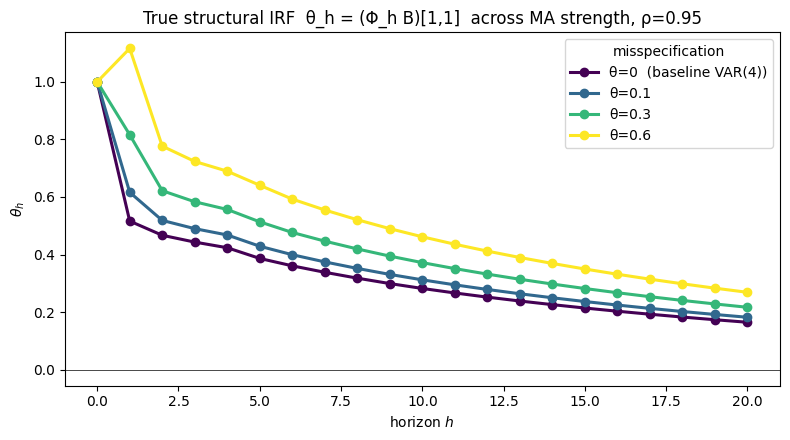

In [17]:
# True structural IRFs (no estimation) for each misspecification strength
hgrid = np.arange(H + 1)
truth_byTheta = {th: varma_irf(DGPS[th], H) for th in THETAS}

cth = {th: plt.cm.viridis(i / max(len(THETAS) - 1, 1)) for i, th in enumerate(THETAS)}
fig, ax = plt.subplots(figsize=(8, 4.5))
for th in THETAS:
    lab = "θ=0  (baseline VAR(4))" if th == 0 else f"θ={th}"
    ax.plot(hgrid, truth_byTheta[th], "o-", lw=2.2, color=cth[th], label=lab)
ax.axhline(0, color="k", lw=0.5)
ax.set_title(f"True structural IRF  θ_h = (Φ_h B)[1,1]  across MA strength, ρ={RHO}")
ax.set_xlabel("horizon $h$"); ax.set_ylabel(r"$\theta_h$"); ax.legend(title="misspecification")
fig.tight_layout(); plt.show()

## 2. Monte Carlo — LP(4) + VAR(q) sweep × misspecification × sample size

The three-way design of Ch. 4: for each $\theta\in\{0,0.1,0.3,0.6\}$ and $T\in\{100,200,240,500\}$ we run the fixed **LP(4)** and the full **VAR(q) sweep** ($q=1\ldots23$) on VARMA-generated data, **without modification**. The estimand is $T$-independent but **$\theta$-dependent** (`truth_byTheta`). Raw stacks land in `results[(θ,T)]` and horizon-wise RMSE in `rmse[(θ,T)]`.

In [18]:
VAR_ORDERS = list(range(1, P + H))                  # 1, 2, ..., 22, 23

estimators = {"LP(4)": partial(estimate_lp_irf, p=P, horizon=H)}
estimators.update({f"VAR({q})": partial(estimate_var_irf, p=q, horizon=H) for q in VAR_ORDERS})


def varma_dgp(rng, Tlen, spec):
    return simulate_varma(spec, Tlen, rng)


results, rmse = {}, {}                               # keyed by (theta, T)
for th in THETAS:
    truth = truth_byTheta[th]                        # estimand depends on theta
    for Tval in T:
        cfg = MCConfig(n_reps=N_REPS, T=Tval, horizon=H, seed=42, n_jobs=-1,
                       progress=True, estimators=estimators)
        res = run(partial(varma_dgp, spec=DGPS[th]), cfg)
        results[(th, Tval)] = res
        rmse[(th, Tval)] = {nm: np.sqrt(np.nanmean((st - truth) ** 2, axis=0))
                            for nm, st in res["irfs"].items()}
        fails = {k: v for k, v in res["n_failures"].items() if v}
        print(f"theta={th:<4} T={Tval:>4}: done  |  failures: {fails or 'none'}")

MC reps: 100%|██████████| 5000/5000 [00:03<00:00, 1328.08it/s]


theta=0.0  T= 100: done  |  failures: none


MC reps: 100%|██████████| 5000/5000 [00:04<00:00, 1087.59it/s]


theta=0.0  T= 200: done  |  failures: none


MC reps: 100%|██████████| 5000/5000 [00:04<00:00, 1122.15it/s]


...

theta=0.6  T= 200: done  |  failures: none


MC reps: 100%|██████████| 5000/5000 [00:05<00:00, 903.89it/s]


theta=0.6  T= 240: done  |  failures: none


MC reps: 100%|██████████| 5000/5000 [00:07<00:00, 704.96it/s]


theta=0.6  T= 500: done  |  failures: none


## 3. RMSE comparison: does the ranking survive misspecification?

The **complexity frontier** (horizon-averaged RMSE vs VAR order) at $T=240$, one curve per $\theta$, with LP(4) as a same-colour dashed reference. As $\theta$ grows the equal-lag (VAR(4)) end of the frontier should lift — four lags cannot fit the MA dynamics — while higher-order VARs and LP(4) absorb it. The table reports every $(\theta,T)$ cell.

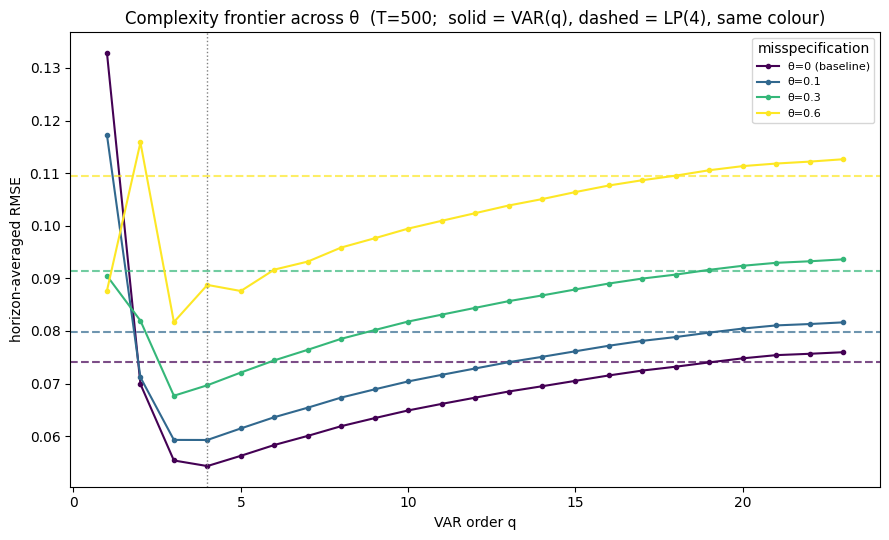

 theta     T    LP(4)   VAR(4)        bestVAR   LP-VAR4
--------------------------------------------------------
   0.0   100    0.197    0.137   VAR(3)=0.133    +0.060
   0.0   200    0.126    0.092   VAR(3)=0.091    +0.035
   0.0   240    0.113    0.082   VAR(4)=0.082    +0.031
   0.0   500    0.074    0.054   VAR(4)=0.054    +0.020
   0.1   100    0.213    0.150   VAR(3)=0.145    +0.063
   0.1   200    0.136    0.100   VAR(3)=0.098    +0.036
   0.1   240    0.122    0.090   VAR(3)=0.089    +0.032
   0.1   500    0.080    0.059   VAR(4)=0.059    +0.020
   0.3   100    0.246    0.177   VAR(3)=0.169    +0.068
   0.3   200    0.156    0.118   VAR(3)=0.114    +0.038
   0.3   240    0.140    0.106   VAR(3)=0.103    +0.034
   0.3   500    0.091    0.070   VAR(3)=0.068    +0.022
   0.6   100    0.297    0.222   VAR(1)=0.195    +0.075
   0.6   200    0.188    0.149   VAR(1)=0.136    +0.039
   0.6   240    0.168    0.134   VAR(3)=0.123    +0.034
   0.6   500    0.109    0.089   VAR(3)=0.082  

In [19]:
# (1) complexity frontier per theta, at T_SHOW
fig, ax = plt.subplots(figsize=(9, 5.5))
for th in THETAS:
    rm = rmse[(th, T_SHOW)]
    avg_var = [np.mean(rm[f"VAR({q})"]) for q in VAR_ORDERS]
    lab = "θ=0 (baseline)" if th == 0 else f"θ={th}"
    ax.plot(VAR_ORDERS, avg_var, "o-", ms=3, color=cth[th], label=lab)
    ax.axhline(np.mean(rm["LP(4)"]), ls="--", color=cth[th], alpha=0.7)
ax.axvline(4, color="gray", ls=":", lw=1)
ax.set_title(f"Complexity frontier across θ  (T={T_SHOW};  solid = VAR(q), dashed = LP(4), same colour)")
ax.set_xlabel("VAR order q"); ax.set_ylabel("horizon-averaged RMSE")
ax.legend(fontsize=8, title="misspecification")
fig.tight_layout(); plt.show()

# (2) full (theta, T) summary table
print(f"{'theta':>6} {'T':>5} {'LP(4)':>8} {'VAR(4)':>8} {'bestVAR':>14} {'LP-VAR4':>9}")
print("-" * 56)
for th in THETAS:
    for Tval in T:
        rm = rmse[(th, Tval)]
        lp = float(np.mean(rm["LP(4)"])); v4 = float(np.mean(rm["VAR(4)"]))
        avgs = {q: float(np.mean(rm[f"VAR({q})"])) for q in VAR_ORDERS}
        bq = min(avgs, key=avgs.get)
        print(f"{th:>6} {Tval:>5} {lp:8.3f} {v4:8.3f} {f'VAR({bq})={avgs[bq]:.3f}':>14} {lp - v4:+9.3f}")
print("(horizon-averaged RMSE;  LP-VAR4 > 0 = VAR(4) better)")

### RMSE by horizon, per misspecification strength

One panel per $\theta$ at $T=240$: the VAR sweep (dark = low order → yellow = high) with LP(4) and the equal-lag VAR(4) highlighted. Misspecification bias concentrates at short horizons (where $\Theta u_{t-1}$ acts), so watch VAR(4) lift there as $\theta$ grows while LP(4) stays flat.

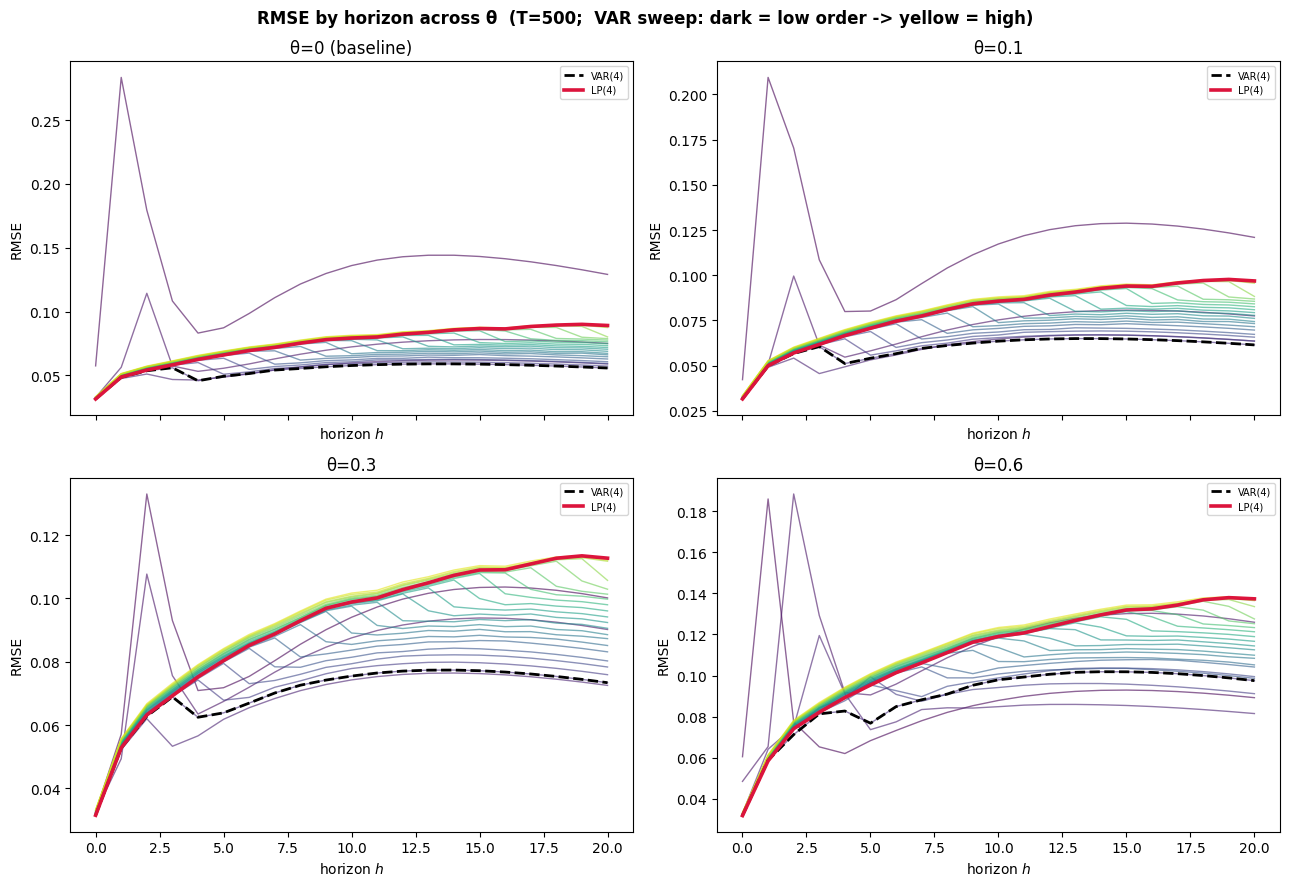

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharex=True)
for ax, th in zip(axes.ravel(), THETAS):
    rm = rmse[(th, T_SHOW)]
    for i, q in enumerate(VAR_ORDERS):
        ax.plot(hgrid, rm[f"VAR({q})"], color=plt.cm.viridis(i / len(VAR_ORDERS)), lw=1, alpha=0.6)
    ax.plot(hgrid, rm["VAR(4)"], "k--", lw=2, label="VAR(4)")
    ax.plot(hgrid, rm["LP(4)"], color="crimson", lw=2.6, label="LP(4)")
    ttl = "θ=0 (baseline)" if th == 0 else f"θ={th}"
    ax.set_title(ttl); ax.set_xlabel("horizon $h$"); ax.set_ylabel("RMSE"); ax.legend(fontsize=7)
fig.suptitle(f"RMSE by horizon across θ  (T={T_SHOW};  VAR sweep: dark = low order -> yellow = high)", fontweight="bold")
fig.tight_layout(); plt.show()

## 4. The misspecification channel — finite-sample vs asymptotic bias

Where does the MA term bite, and does LP's theoretical robustness actually help? **Left** ($T=240$, strongest $\theta=0.6$): in finite samples VAR(4) and LP(4) carry **comparable** bias — LP's asymptotic robustness is swamped by finite-sample noise, and its shock is itself identified from a *misspecified* first-stage VAR(4). **Right** (a dedicated large-$T$ probe, $T=4000$): the Ch. 4 theory becomes visible — the equal-lag **VAR(4)** cannot represent the VARMA(4,1), so its bias settles at a **non-zero asymptotic floor**, while **LP(4)** is asymptotically unbiased \[olea2025local\] and collapses to ≈0 at every horizon. The separation emerges only far beyond the empirically relevant $T\le500$, which is why VAR(4) keeps its RMSE edge throughout §3.

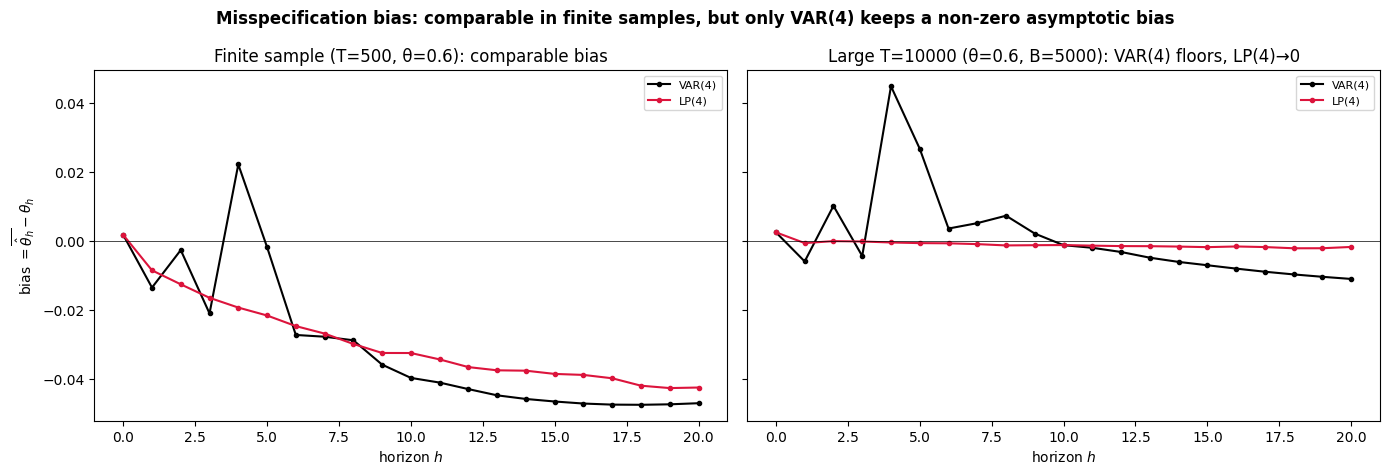

In [ ]:
from joblib import Parallel, delayed

fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 4.8), sharey=True)

# (left) finite-sample bias by horizon at T_SHOW, θ=0.6: VAR(4) ≈ LP(4)
for nm, c in [("VAR(4)", "black"), ("LP(4)", "crimson")]:
    bias = np.nanmean(results[(0.6, T_SHOW)]["irfs"][nm], axis=0) - truth_byTheta[0.6]
    a1.plot(hgrid, bias, "o-", ms=3, color=c, label=nm)
a1.axhline(0, color="k", lw=0.5)
a1.set_title(f"Finite sample (T={T_SHOW}, θ=0.6): comparable bias")
a1.set_xlabel("horizon $h$"); a1.set_ylabel(r"bias $=\overline{\hat\theta_h}-\theta_h$")
a1.legend(fontsize=8)

# (right) dedicated large-T probe at θ=0.6: the asymptotic separation (Ch. 4 theory).
TH_A, T_ASY, N_ASY = 0.6, 10000, 2000            # large T to expose VAR(4)'s asymptotic bias floor
spec_a, tr_a = DGPS[TH_A], truth_byTheta[TH_A]


def _bias_rep(seed):
    rng = np.random.default_rng(seed)
    y = simulate_varma(spec_a, T_ASY, rng)
    with np.errstate(divide="ignore", over="ignore", invalid="ignore"):
        return estimate_var_irf(y, 4, H), estimate_lp_irf(y, 4, H)


seeds = np.random.SeedSequence(42).spawn(N_ASY)
out = Parallel(n_jobs=-1)(delayed(_bias_rep)(s) for s in seeds)
for nm, idx, c in [("VAR(4)", 0, "black"), ("LP(4)", 1, "crimson")]:
    bias = np.nanmean([o[idx] for o in out], axis=0) - tr_a
    a2.plot(hgrid, bias, "o-", ms=3, color=c, label=nm)
a2.axhline(0, color="k", lw=0.5)
a2.set_title(f"Large T={T_ASY} (θ={TH_A}, B={N_ASY}): VAR(4) floors, LP(4)→0")
a2.set_xlabel("horizon $h$"); a2.legend(fontsize=8)
fig.suptitle("Misspecification bias: comparable in finite samples, but only VAR(4) keeps a non-zero asymptotic bias",
             fontweight="bold")
fig.tight_layout(); plt.show()

### Predicted IRF vs the truth — deviation view

For each estimator at $T=240$, the **deviation of the mean prediction from the truth** ($\hat\theta_h-\theta_h$; the true IRF is the zero line) with the central 90% band (5th–95th pct of the per-replication deviations). The mean line is *bias*; band width is *dispersion* — the two ingredients of RMSE. At this sample size VAR(4) and LP(4) sit almost **on top of each other** and both dip below zero at short horizons as $\theta$ grows: their finite-sample bias is comparable (LP's shock is itself recovered from a misspecified first-stage VAR(4)), and the wide overlapping bands show variance dominates. The two only separate at much larger $T$ (next cell).

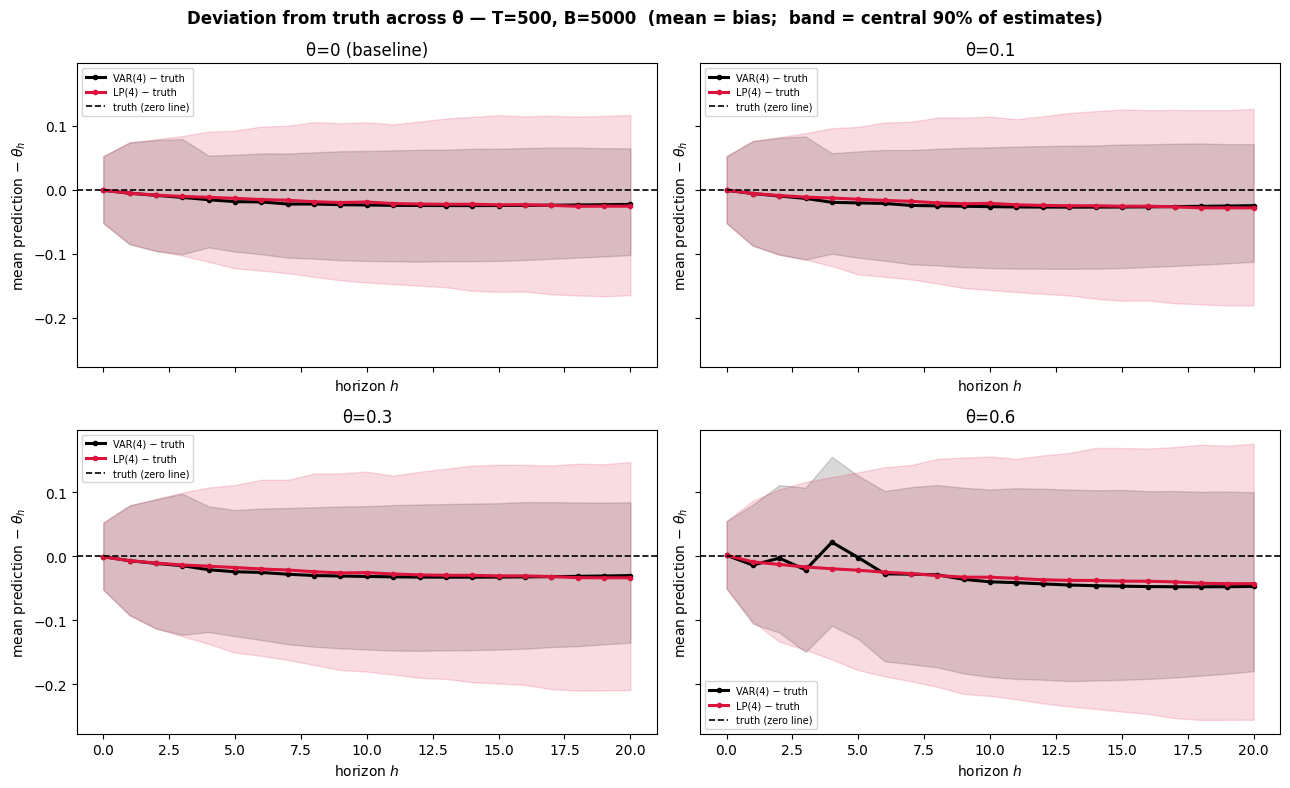

In [29]:
selp = ["VAR(4)", "LP(4)"]
colp = {"VAR(4)": "black", "LP(4)": "crimson"}

fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True, sharey=True)
for ax, th in zip(axes.ravel(), THETAS):
    tr = truth_byTheta[th]
    for nm in selp:
        dev = results[(th, T_SHOW)]["irfs"][nm] - tr      # deviation from truth, per replication
        mean = np.nanmean(dev, axis=0)
        lo, hi = np.nanpercentile(dev, [5, 95], axis=0)
        ax.fill_between(hgrid, lo, hi, color=colp[nm], alpha=0.15)
        ax.plot(hgrid, mean, "o-", ms=3, color=colp[nm], lw=2.2, label=f"{nm} − truth")
    ax.axhline(0, color="k", lw=1.2, ls="--", label="truth (zero line)")
    ttl = "θ=0 (baseline)" if th == 0 else f"θ={th}"
    ax.set_title(ttl); ax.set_xlabel("horizon $h$")
    ax.set_ylabel(r"mean prediction $-\ \theta_h$"); ax.legend(fontsize=7)
fig.suptitle(f"Deviation from truth across θ — T={T_SHOW}, B={N_REPS}  "
             f"(mean = bias;  band = central 90% of estimates)", fontweight="bold")
fig.tight_layout(); plt.show()

#### Asymptotic check, the same view at $T=10000$

At $T=10000$ sampling dispersion is tiny, so the **levels** of both predictions lie essentially on the true IRF — plotted as levels, LP(4), VAR(4) and the truth are indistinguishable. To expose the residual structure we instead plot the **deviation of the mean prediction from the truth** ($\hat\theta_h-\theta_h$; the true IRF is now the zero line). **LP(4)** is flat at zero — it converges to the truth at every horizon. **VAR(4)** retains a small but **non-vanishing** bias at the short horizons where $\Theta u_{t-1}$ acts ($\approx0.045$ at $h=4$, ~4% of the IRF peak): the asymptotic bias of the misspecified equal-lag VAR, which no increase in $T$ removes. The effect is real but modest — which is exactly why in finite samples it is swamped by variance and VAR(4) keeps its RMSE edge (§3). Computed by a dedicated MC at $T=10000$ (not part of §2's grid).

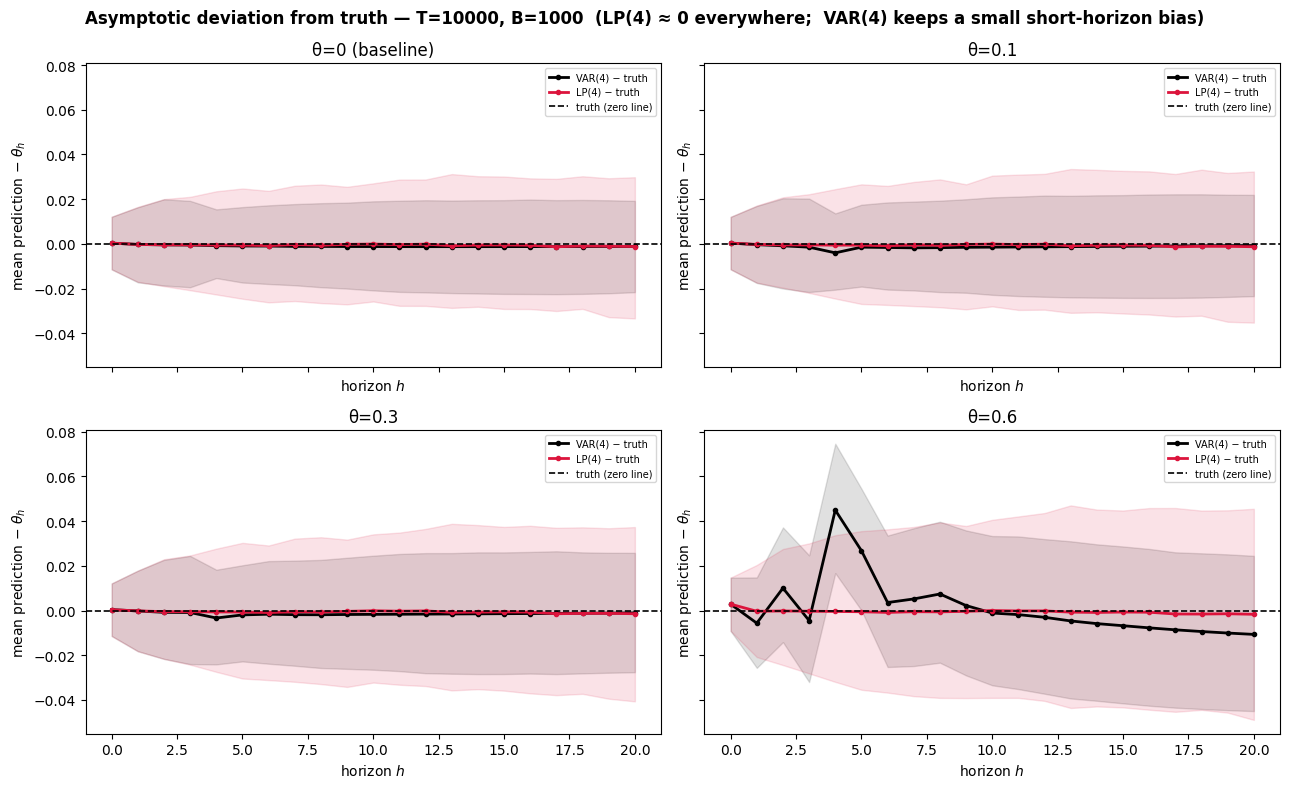

In [28]:
from joblib import Parallel, delayed
from tqdm import tqdm

# Asymptotic check at large T (dedicated MC, not part of §2's grid). At this T the
# *levels* of both predictions lie on the truth, so we plot the deviation from truth
# (estimate - truth) to expose VAR(4)'s residual, non-vanishing bias.
T_ASY2, N_ASY2 = 10000, 1000
colp = {"VAR(4)": "black", "LP(4)": "crimson"}


def _pred_rep(seed, spec):
    rng = np.random.default_rng(seed)
    y = simulate_varma(spec, T_ASY2, rng)
    with np.errstate(divide="ignore", over="ignore", invalid="ignore"):
        return estimate_var_irf(y, 4, H), estimate_lp_irf(y, 4, H)


fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True, sharey=True)
for ax, th in zip(axes.ravel(), THETAS):
    tr = truth_byTheta[th]
    seeds = np.random.SeedSequence(2024).spawn(N_ASY2)
    out = Parallel(n_jobs=-1)(delayed(_pred_rep)(s, DGPS[th])
                              for s in tqdm(seeds, desc=f"asymptotic pred θ={th}", leave=False))
    stacks = {"VAR(4)": np.array([o[0] for o in out]),
              "LP(4)":  np.array([o[1] for o in out])}
    for nm in ("VAR(4)", "LP(4)"):
        dev = stacks[nm] - tr                        # deviation from truth, per replication
        mean = np.nanmean(dev, axis=0)
        lo, hi = np.nanpercentile(dev, [5, 95], axis=0)
        ax.fill_between(hgrid, lo, hi, color=colp[nm], alpha=0.12)
        ax.plot(hgrid, mean, "o-", ms=3, color=colp[nm], lw=2.0, label=f"{nm} − truth")
    ax.axhline(0, color="k", lw=1.2, ls="--", label="truth (zero line)")
    ttl = "θ=0 (baseline)" if th == 0 else f"θ={th}"
    ax.set_title(ttl); ax.set_xlabel("horizon $h$")
    ax.set_ylabel(r"mean prediction $-\ \theta_h$"); ax.legend(fontsize=7)
fig.suptitle(f"Asymptotic deviation from truth — T={T_ASY2}, B={N_ASY2}  "
             f"(LP(4) ≈ 0 everywhere;  VAR(4) keeps a small short-horizon bias)", fontweight="bold")
fig.tight_layout(); plt.show()

## 5. Point-estimation metrics under misspecification (Ch. 3 metrics)

Same per-horizon **bias / variance / MSE / RMSE** decomposition as the baseline, now at the strongest misspecification $\theta=0.6$, $T=240$. Unlike the correctly-specified baseline (VAR bias ≈ 0), here low-order VARs carry genuine bias, so $\mathrm{MSE}_h=\mathrm{Bias}_h^2+\mathrm{Var}_h$ has a non-negligible squared-bias component at short horizons. $\mathrm{MCSE}(\widehat{\mathrm{Bias}}_h)=\sqrt{\widehat{\mathrm{Var}}_h/B}$ bounds simulation noise.

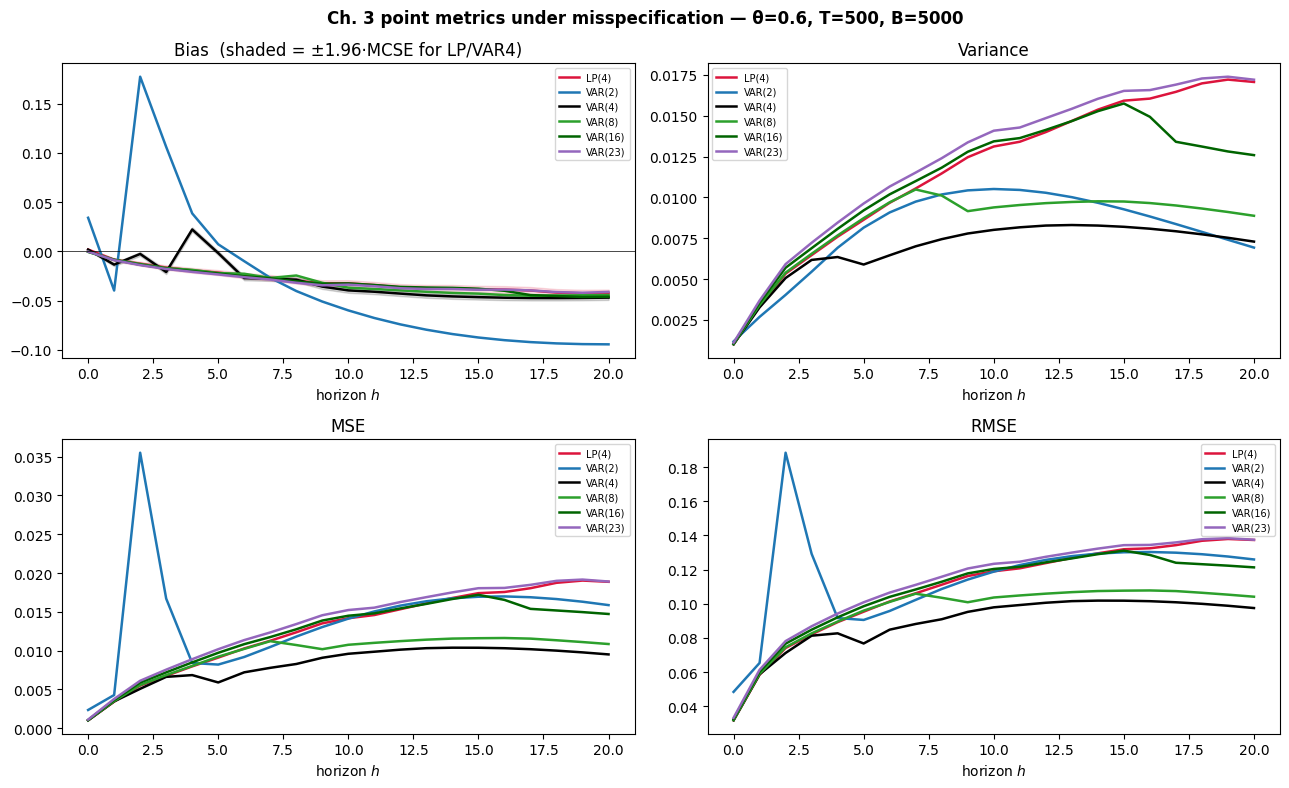

θ=0.6, T=500, B=5000   |   typical MCSE(bias) ~ 0.0011


h=1             h=8            h=20        
           bias    RMSE    bias    RMSE    bias    RMSE
LP(4)   -0.0085  0.0585 -0.0299  0.1112 -0.0425  0.1374
VAR(2)  -0.0398  0.0654 -0.0404  0.1087 -0.0945  0.1260
VAR(4)  -0.0135  0.0588 -0.0288  0.0910 -0.0471  0.0975
VAR(8)  -0.0085  0.0590 -0.0246  0.1035 -0.0444  0.1042
VAR(16) -0.0087  0.0602 -0.0305  0.1129 -0.0462  0.1213
VAR(23) -0.0090  0.0614 -0.0320  0.1158 -0.0413  0.1375

In [23]:
import pandas as pd
from IPython.display import display


def metrics(stack, truth):
    """Per-horizon Ch. 3 point metrics for a (B, H+1) stack of IRF estimates."""
    B = int(np.sum(~np.isnan(stack[:, 0])))
    mean = np.nanmean(stack, axis=0)
    bias = mean - truth
    var = np.nanvar(stack, axis=0, ddof=1)
    mse = np.nanmean((stack - truth) ** 2, axis=0)
    return dict(bias=bias, var=var, mse=mse, rmse=np.sqrt(mse),
                mcse_bias=np.sqrt(var / B), B=B)


TH_SHOW, Tval = 0.6, T_SHOW                          # strongest misspecification cell
truth = truth_byTheta[TH_SHOW]
sel = ["LP(4)", "VAR(2)", "VAR(4)", "VAR(8)", "VAR(16)", "VAR(23)"]
colm = {"LP(4)": "crimson", "VAR(2)": "tab:blue", "VAR(4)": "black",
        "VAR(8)": "tab:green", "VAR(16)": "darkgreen", "VAR(23)": "tab:purple"}
m = {nm: metrics(results[(TH_SHOW, Tval)]["irfs"][nm], truth) for nm in sel}

fig, ax = plt.subplots(2, 2, figsize=(13, 8))
for nm in sel:
    ax[0, 0].plot(hgrid, m[nm]["bias"], color=colm[nm], lw=1.8, label=nm)
    ax[0, 1].plot(hgrid, m[nm]["var"], color=colm[nm], lw=1.8, label=nm)
    ax[1, 0].plot(hgrid, m[nm]["mse"], color=colm[nm], lw=1.8, label=nm)
    ax[1, 1].plot(hgrid, m[nm]["rmse"], color=colm[nm], lw=1.8, label=nm)
for nm in ("LP(4)", "VAR(4)"):                       # MCSE band on bias (sim. uncertainty)
    lo, hi = m[nm]["bias"] - 1.96 * m[nm]["mcse_bias"], m[nm]["bias"] + 1.96 * m[nm]["mcse_bias"]
    ax[0, 0].fill_between(hgrid, lo, hi, color=colm[nm], alpha=0.15)
ax[0, 0].axhline(0, color="k", lw=0.5)
ax[0, 0].set_title("Bias  (shaded = ±1.96·MCSE for LP/VAR4)")
ax[0, 1].set_title("Variance"); ax[1, 0].set_title("MSE"); ax[1, 1].set_title("RMSE")
for a in ax.ravel():
    a.set_xlabel("horizon $h$"); a.legend(fontsize=7)
fig.suptitle(f"Ch. 3 point metrics under misspecification — θ={TH_SHOW}, T={Tval}, B={N_REPS}",
             fontweight="bold")
fig.tight_layout(); plt.show()

# compact table: bias and RMSE at selected horizons
report = [1, 8, 20]
rows = {nm: {(f"h={h}", k): m[nm][{"bias": "bias", "RMSE": "rmse"}[k]][h]
             for h in report for k in ("bias", "RMSE")} for nm in sel}
tab = pd.DataFrame(rows).T
tab.columns = pd.MultiIndex.from_tuples(tab.columns)
print(f"θ={TH_SHOW}, T={Tval}, B={N_REPS}   |   typical MCSE(bias) ~ "
      f"{np.mean([m['VAR(4)']['mcse_bias'][h] for h in report]):.4f}")
display(tab.round(4))

## 6. Inference — coverage under misspecification (Ch. 3)

Coverage of nominal 95% CIs for the **true** VARMA $\theta_h$. The CI machinery is unchanged from the baseline:

* **VAR(q): delta method** — propagates reduced-form coefficient uncertainty through $\theta_h=\hat\Psi_h\hat B e_1$ (variance only; $B$ held fixed).
* **LP(4): HC1-robust SE** of the shock coefficient.

A variance-only CI ignores bias, so under misspecification it can only *miss* the truth more often as bias grows. At the empirically relevant $T=240$ both estimators **mildly under-cover**, worst at the short horizons where the MA term bites, and by similar amounts — consistent with §4 (comparable finite-sample bias; LP's shock is itself identified from a misspecified VAR(4)). The validation panel (delta SE vs empirical SD at $\theta=0.6$) confirms the SE still tracks the sampling dispersion, so the under-coverage is a *bias* effect, not a broken SE.

coverage MC θ=0.6: 100%|██████████| 5000/5000 [00:05<00:00, 901.28it/s]


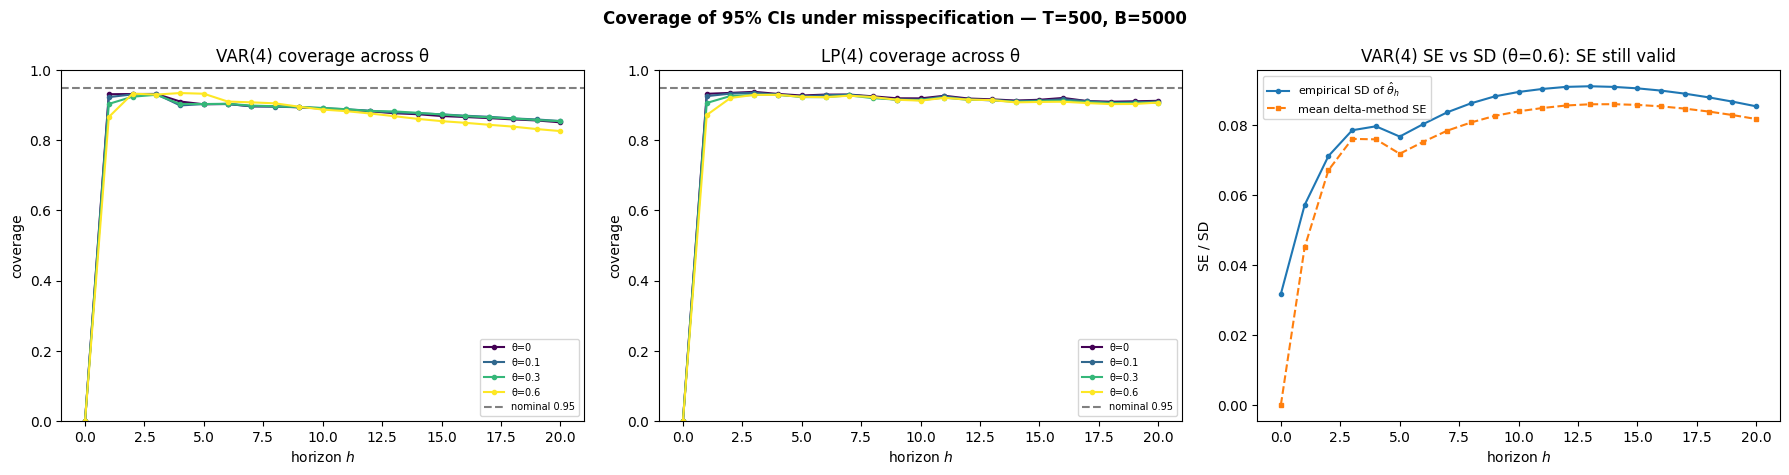

horizon-averaged coverage:
   VAR(4): θ=0.0:0.847   θ=0.1:0.847   θ=0.3:0.846   θ=0.6:0.840
    LP(4): θ=0.0:0.879   θ=0.1:0.877   θ=0.3:0.873   θ=0.6:0.871


In [24]:
from joblib import Parallel, delayed
from tqdm import tqdm
from mcsim.dgp import var_ma_matrices
from mcsim.estimators import fit_var_ols
from mcsim.coverage import var_theta_se, lp_theta_se

T_COV = T_SHOW         # one sample-size cell (Ch. 3 would sweep T as in section 2)
N_COV = 5000           # replications for the coverage MC
Z = 1.96               # normal critical value for a nominal 95% two-sided CI
EST_COV = ["VAR(4)", "LP(4)"]   # headline pair: misspecified equal-lag VAR vs robust LP

def _coverage_rep(seed, spec):
    """One replication: simulate from the VARMA spec, return {estimator: (theta_hat, se)}."""
    rng = np.random.default_rng(seed)
    y = simulate_varma(spec, T_COV, rng)
    with np.errstate(divide="ignore", over="ignore", invalid="ignore"):
        return {"VAR(4)": var_theta_se(y, 4, H),
                "LP(4)":  lp_theta_se(y, 4, H)}


coverage = {}          # theta -> {estimator: coverage_h}
val = {}               # SE-vs-SD validation at the strongest theta
for th in THETAS:
    tr = truth_byTheta[th]
    # Independent, reproducible RNG stream per replication (parallel-safe), as in mcsim.run.
    seeds = np.random.SeedSequence(42).spawn(N_COV)
    reps = Parallel(n_jobs=-1)(delayed(_coverage_rep)(s, DGPS[th])
                               for s in tqdm(seeds, desc=f"coverage MC θ={th}"))
    theta_s = {nm: np.array([r[nm][0] for r in reps]) for nm in EST_COV}
    se_s = {nm: np.array([r[nm][1] for r in reps]) for nm in EST_COV}
    # Coverage_h = fraction of CIs [theta_hat +/- Z*se] that contain the TRUE theta_h.
    coverage[th] = {nm: np.nanmean((theta_s[nm] - Z * se_s[nm] <= tr) &
                                   (tr <= theta_s[nm] + Z * se_s[nm]), axis=0) for nm in EST_COV}
    if th == 0.6:      # validation: delta-method SE should still match the empirical SD
        val = dict(emp=np.nanstd(theta_s["VAR(4)"], axis=0, ddof=1),
                   se=np.nanmean(se_s["VAR(4)"], axis=0))

# --- coverage per estimator (one curve per theta) + SE validation ----------------
fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))
for ax, nm in zip(axes[:2], EST_COV):
    for th in THETAS:
        lab = "θ=0" if th == 0 else f"θ={th}"
        ax.plot(hgrid, coverage[th][nm], "o-", ms=3, color=cth[th], label=lab)
    ax.axhline(0.95, color="gray", ls="--", label="nominal 0.95")
    ax.set_ylim(0, 1); ax.set_xlabel("horizon $h$"); ax.set_ylabel("coverage")
    ax.set_title(f"{nm} coverage across θ"); ax.legend(fontsize=7)

axv = axes[2]
axv.plot(hgrid, val["emp"], "o-", ms=3, label="empirical SD of $\\hat\\theta_h$")
axv.plot(hgrid, val["se"], "s--", ms=3, label="mean delta-method SE")
axv.set_xlabel("horizon $h$"); axv.set_ylabel("SE / SD")
axv.set_title("VAR(4) SE vs SD (θ=0.6): SE still valid"); axv.legend(fontsize=8)
fig.suptitle(f"Coverage of 95% CIs under misspecification — T={T_COV}, B={N_COV}", fontweight="bold")
fig.tight_layout(); plt.show()

print("horizon-averaged coverage:")
for nm in EST_COV:
    print(f"  {nm:>7}: " + "   ".join(f"θ={th}:{np.nanmean(coverage[th][nm]):.3f}" for th in THETAS))